In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import (
    freqz,
    group_delay,
    lfilter
)

In [2]:
data = loadmat("gdeldata.mat")

x1    = data["x1"].squeeze()
noise = data["noise"].squeeze()

pulse = data["pulse"].squeeze()

h = data["h"].squeeze()

a = data["a"].squeeze()
b = data["b"].squeeze()

pnd_1 = data["pnd_1"].squeeze()

# 1. Atraso de Grupo de um Atraso Ideal

Considere um sistema que implementa um atraso puro de \(D\) amostras:

$$
H(e^{j\omega}) = e^{-j\omega D}
$$

A fase desse sistema é dada por:

$$
\angle H(e^{j\omega}) = -\omega D
$$

O atraso de grupo é definido como:

$$
\tau_g(\omega)
=
-\frac{d}{d\omega}
\left[
\angle H(e^{j\omega})
\right]
$$

Substituindo a expressão da fase:

$$
\tau_g(\omega)
=
-\frac{d}{d\omega}
(-\omega D)
$$

Resultando em:

$$
\tau_g(\omega)
=
D
$$

Portanto, o atraso de grupo de um atraso ideal é constante para todas as frequências.

Isso significa que todas as componentes espectrais sofrem exatamente o mesmo atraso temporal, preservando a forma de onda dos sinais transmitidos pelo sistema.

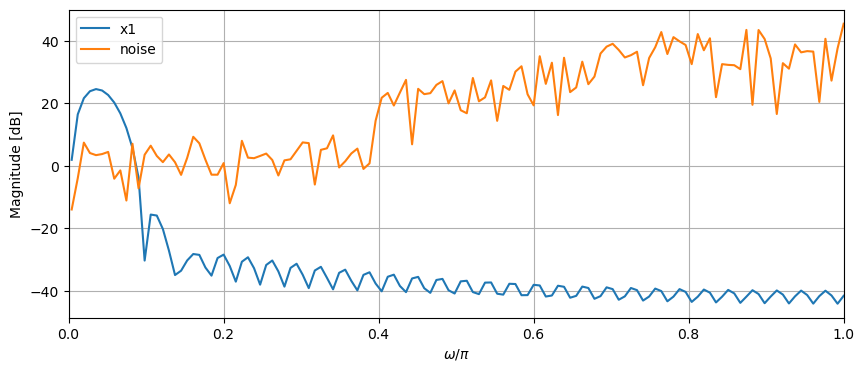

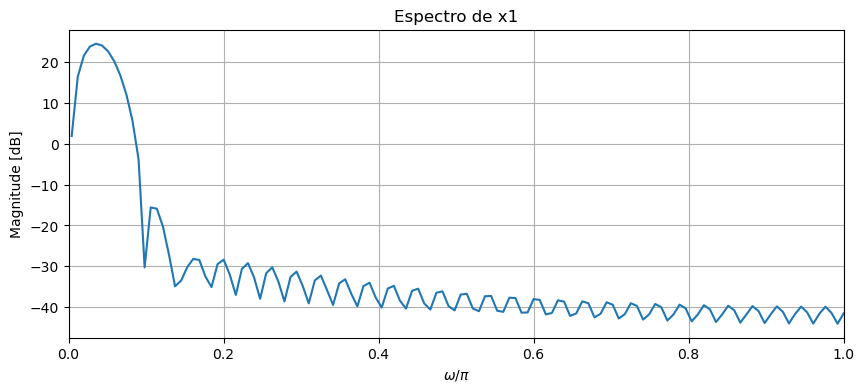

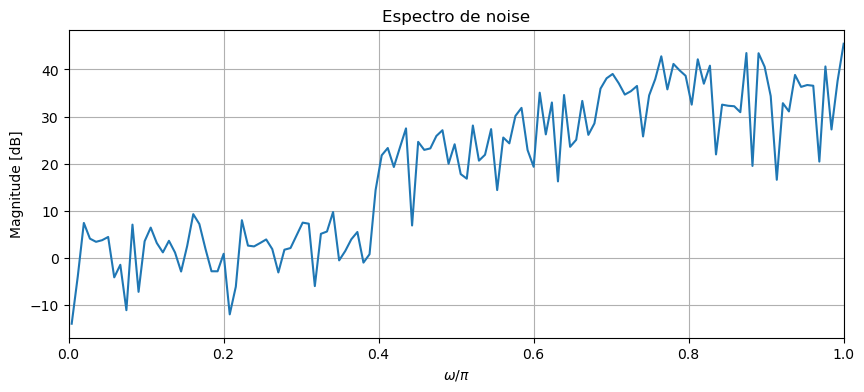

In [3]:
N = len(x1)

X1 = np.fft.fftshift(np.fft.fft(x1))
NOISE = np.fft.fftshift(np.fft.fft(noise))

w = np.linspace(-1, 1, N)

idx = w >= 0

X1_db = 20*np.log10(np.abs(X1) + 1e-12)
NOISE_db = 20*np.log10(np.abs(NOISE) + 1e-12)

plt.figure(figsize=(10,4))

plt.plot(w[idx], X1_db[idx], label='x1')
plt.plot(w[idx], NOISE_db[idx], label='noise')

plt.xlabel(r'$\omega/\pi$')
plt.ylabel('Magnitude [dB]')

plt.xlim(0,1)

plt.grid()
plt.legend()

plt.show()

plt.figure(figsize=(10,4))

plt.plot(w[idx], X1_db[idx])

plt.title('Espectro de x1')
plt.xlabel(r'$\omega/\pi$')
plt.ylabel('Magnitude [dB]')

plt.xlim(0,1)

plt.grid()

plt.show()

plt.figure(figsize=(10,4))

plt.plot(w[idx], NOISE_db[idx])

plt.title('Espectro de noise')
plt.xlabel(r'$\omega/\pi$')
plt.ylabel('Magnitude [dB]')

plt.xlim(0,1)

plt.grid()

plt.show()

O sinal e o ruído ocupam bandas distintas. Portanto é possível projetar um filtro seletivo que preserve a banda do sinal e rejeite a banda do ruído.

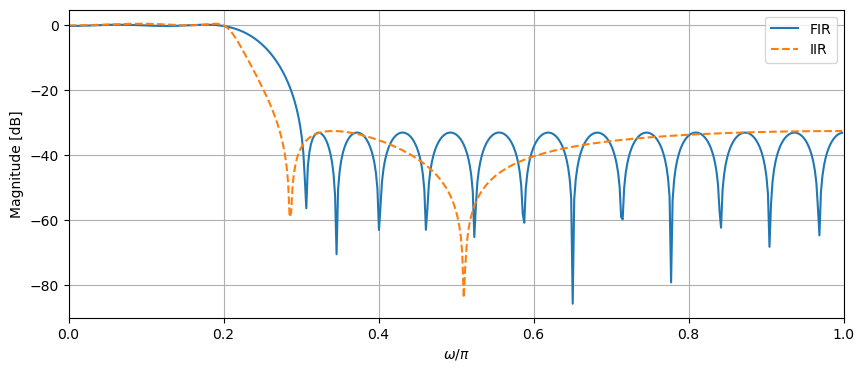

In [4]:
w_fir, Hfir = freqz(h)

w_iir, Hiir = freqz(b, a)

plt.figure(figsize=(10,4))

plt.plot(
    w_fir/np.pi,
    20*np.log10(np.abs(Hfir) + 1e-12),
    label='FIR'
)

plt.plot(
    w_iir/np.pi,
    20*np.log10(np.abs(Hiir) + 1e-12),
    '--',
    label='IIR'
)

plt.ylabel('Magnitude [dB]')

plt.xlabel(r'$\omega/\pi$')

plt.xlim(0, 1)

plt.grid()
plt.legend()

plt.show()

Observando os espectros de (x_1) e (noise), verifica-se que a maior parte da energia do sinal de interesse está concentrada em uma faixa de frequências diferente daquela ocupada pelo ruído. As respostas em magnitude dos filtros FIR e IIR mostram que ambos apresentam banda de passagem na região ocupada por (x_1) e forte atenuação na região onde se concentra o ruído.

Dessa forma, ambos os filtros são capazes de preservar as componentes espectrais relevantes do sinal de interesse enquanto atenuam significativamente as componentes associadas ao ruído, permitindo a recuperação de (x_1).


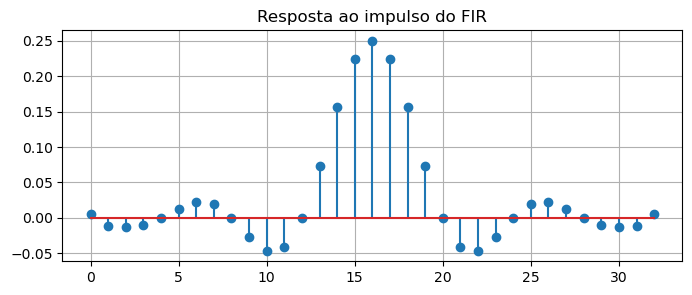

In [5]:
plt.figure(figsize=(8,3))

plt.stem(h)

plt.title("Resposta ao impulso do FIR")
plt.grid()

plt.show()

In [6]:
print(
    "Simétrico:",
    np.allclose(h, h[::-1])
)

Simétrico: True


Como a resposta ao impulso é simétrica, o filtro possui fase linear.

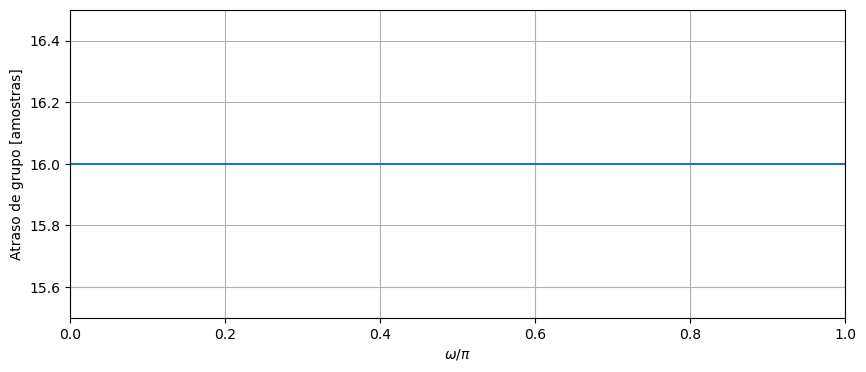

Atraso médio: 16.000000
Desvio padrão: 1.897e-10


In [7]:
wgd_fir, gd_fir = group_delay((h, 1))

plt.figure(figsize=(10,4))

plt.plot(wgd_fir/np.pi, gd_fir)

plt.xlabel(r'$\omega/\pi$')
plt.ylabel('Atraso de grupo [amostras]')

plt.xlim(0,1)
plt.ylim(15.5,16.5)

plt.grid()

plt.show()

print(f"Atraso médio: {np.mean(gd_fir):.6f}")
print(f"Desvio padrão: {np.std(gd_fir):.3e}")

Atraso de grupo constante.

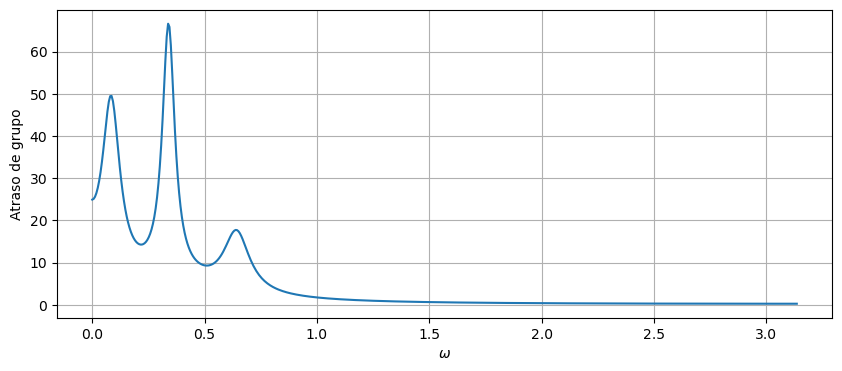

Atraso mínimo : 0.27
Atraso máximo : 66.63
Variação      : 66.36


In [8]:
wgd_iir, gd_iir = group_delay((b, a))

plt.figure(figsize=(10,4))

plt.plot(wgd_iir, gd_iir)

plt.xlabel(r'$\omega$')
plt.ylabel('Atraso de grupo')

plt.grid()
plt.show()

print(f"Atraso mínimo : {np.min(gd_iir):.2f}")
print(f"Atraso máximo : {np.max(gd_iir):.2f}")
print(f"Variação      : {np.max(gd_iir)-np.min(gd_iir):.2f}")

Diferentemente do filtro FIR, o atraso de grupo do filtro IIR não permanece constante ao longo da frequência. Observa-se uma variação significativa entre os valores mínimo e máximo, indicando que diferentes componentes espectrais sofrem atrasos distintos ao atravessar o filtro. Essa característica é responsável pelas distorções temporais observadas posteriormente nos sinais pulsados.


In [9]:
y_fir = lfilter(h, [1], x1)

y_iir = lfilter(b, a, x1)

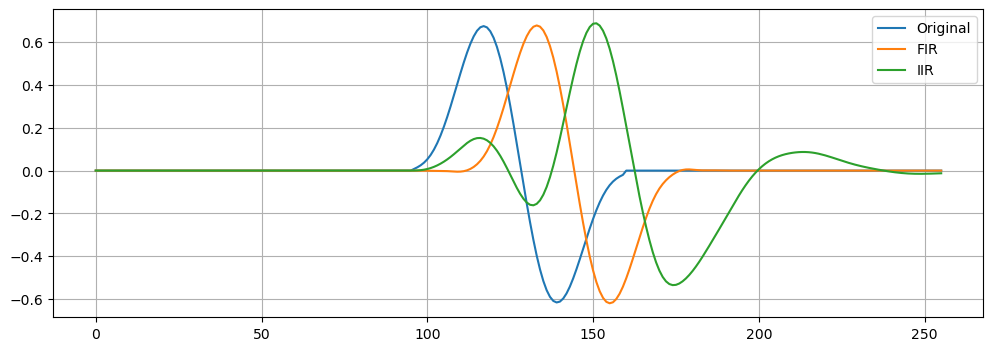

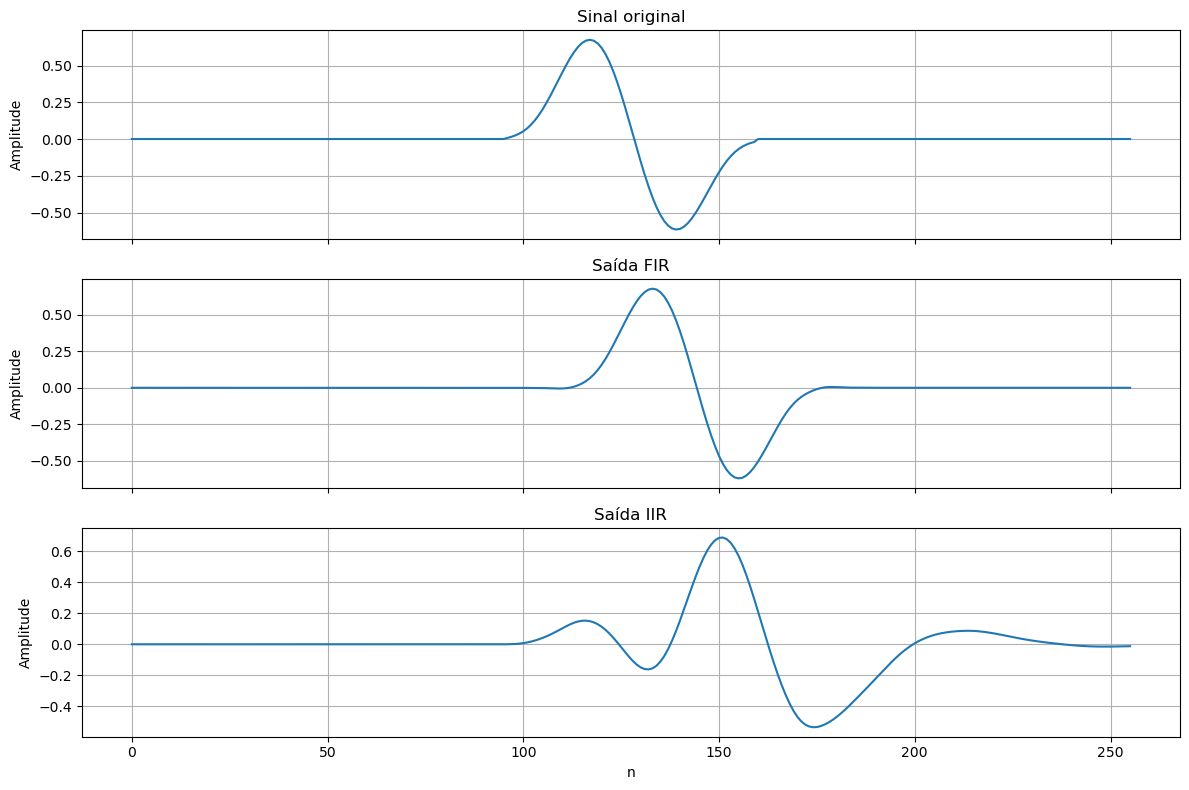

In [10]:
plt.figure(figsize=(12,4))

plt.plot(x1, label='Original')
plt.plot(y_fir, label='FIR')
plt.plot(y_iir, label='IIR')

plt.legend()
plt.grid()

plt.show()

fig, ax = plt.subplots(
    3,
    1,
    figsize=(12,8),
    sharex=True
)

ax[0].plot(x1)
ax[0].set_title('Sinal original')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(y_fir)
ax[1].set_title('Saída FIR')
ax[1].set_ylabel('Amplitude')
ax[1].grid()

ax[2].plot(y_iir)
ax[2].set_title('Saída IIR')
ax[2].set_ylabel('Amplitude')
ax[2].set_xlabel('n')
ax[2].grid()

plt.tight_layout()
plt.show()

Podemos observar uma diferença no atraso entre os dois filtros, bem como uma distorção mais predominante no caso do filtro IIR.

In [11]:
pulse_fir = lfilter(h, [1], pulse)

pulse_iir = lfilter(b, a, pulse)

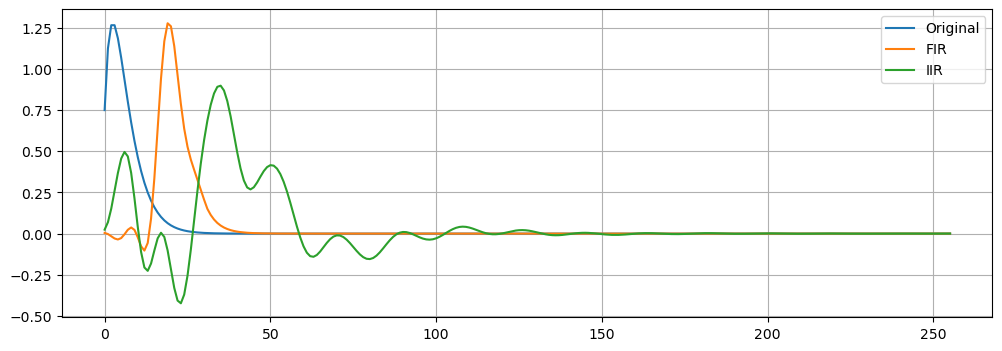

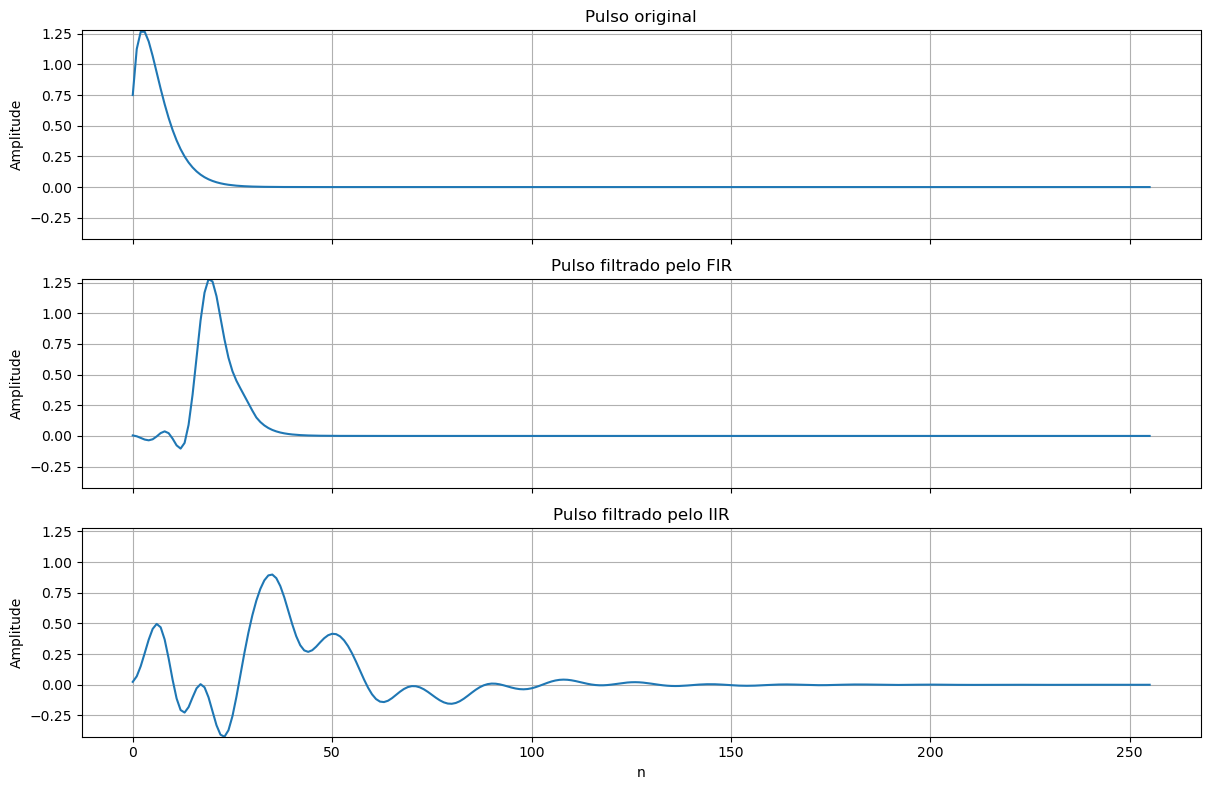

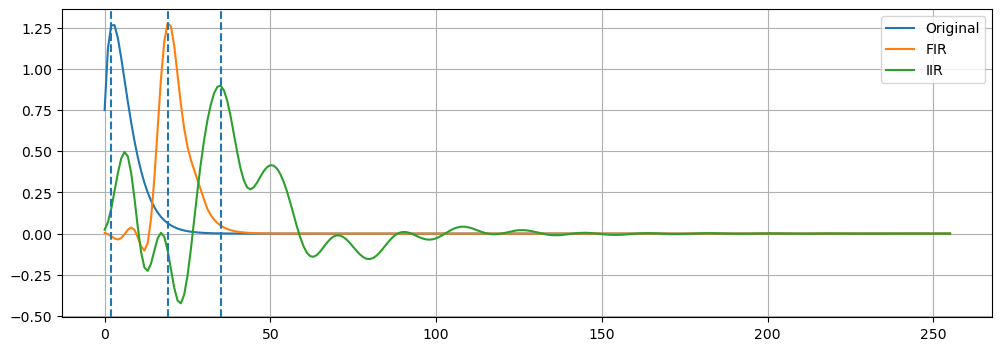


Posição dos picos
------------------
Original : 2
FIR      : 19
IIR      : 35

Atrasos
--------
FIR - Original : 17
IIR - Original : 33


In [12]:
plt.figure(figsize=(12,4))

plt.plot(pulse, label='Original')
plt.plot(pulse_fir, label='FIR')
plt.plot(pulse_iir, label='IIR')

plt.legend()
plt.grid()

plt.show()

fig, ax = plt.subplots(
    3,
    1,
    figsize=(12,8),
    sharex=True
)

ymin = min(
    np.min(pulse),
    np.min(pulse_fir),
    np.min(pulse_iir)
)

ymax = max(
    np.max(pulse),
    np.max(pulse_fir),
    np.max(pulse_iir)
)

ax[0].plot(pulse)
ax[0].set_title('Pulso original')
ax[0].set_ylabel('Amplitude')
ax[0].set_ylim(ymin, ymax)
ax[0].grid()

ax[1].plot(pulse_fir)
ax[1].set_title('Pulso filtrado pelo FIR')
ax[1].set_ylabel('Amplitude')
ax[1].set_ylim(ymin, ymax)
ax[1].grid()

ax[2].plot(pulse_iir)
ax[2].set_title('Pulso filtrado pelo IIR')
ax[2].set_ylabel('Amplitude')
ax[2].set_xlabel('n')
ax[2].set_ylim(ymin, ymax)
ax[2].grid()

plt.tight_layout()
plt.show()

peak_original = np.argmax(pulse)
peak_fir      = np.argmax(pulse_fir)
peak_iir      = np.argmax(pulse_iir)

plt.figure(figsize=(12,4))

plt.plot(pulse, label='Original')
plt.plot(pulse_fir, label='FIR')
plt.plot(pulse_iir, label='IIR')

plt.axvline(peak_original, linestyle='--')
plt.axvline(peak_fir, linestyle='--')
plt.axvline(peak_iir, linestyle='--')

plt.legend()
plt.grid()

plt.show()

print("\nPosição dos picos")
print("------------------")
print(f"Original : {peak_original}")
print(f"FIR      : {peak_fir}")
print(f"IIR      : {peak_iir}")

print("\nAtrasos")
print("--------")
print(f"FIR - Original : {peak_fir - peak_original}")
print(f"IIR - Original : {peak_iir - peak_original}")

O pico detectado na saída do filtro FIR ocorre após a introdução do atraso de grupo constante do próprio filtro. Como esse atraso é aproximadamente conhecido ((\tau_g \approx 16) amostras), pode-se compensá-lo diretamente ao estimar a posição temporal do eco.

Já no filtro IIR não existe uma correção equivalente simples, pois o atraso de grupo depende da frequência. Como diferentes componentes do sinal sofrem atrasos distintos, a posição do pico filtrado não pode ser corrigida por uma única constante. Essa característica reduz a confiabilidade da estimativa temporal em aplicações de radar.

In [13]:
radar_fir = lfilter(h, [1], pnd_1)

radar_iir = lfilter(b, a, pnd_1)

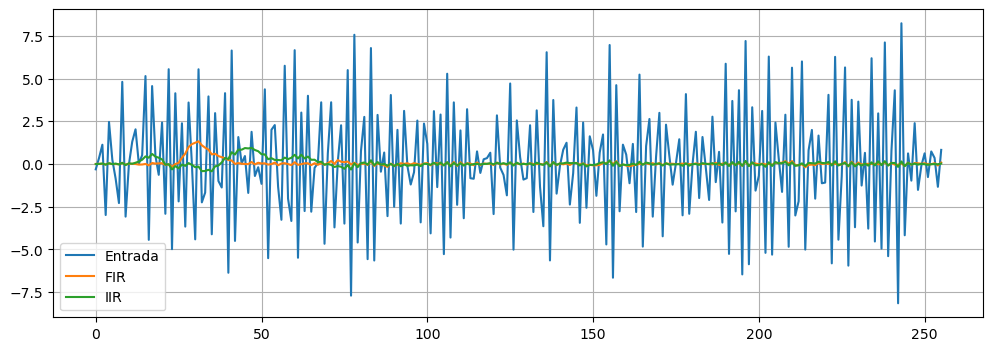

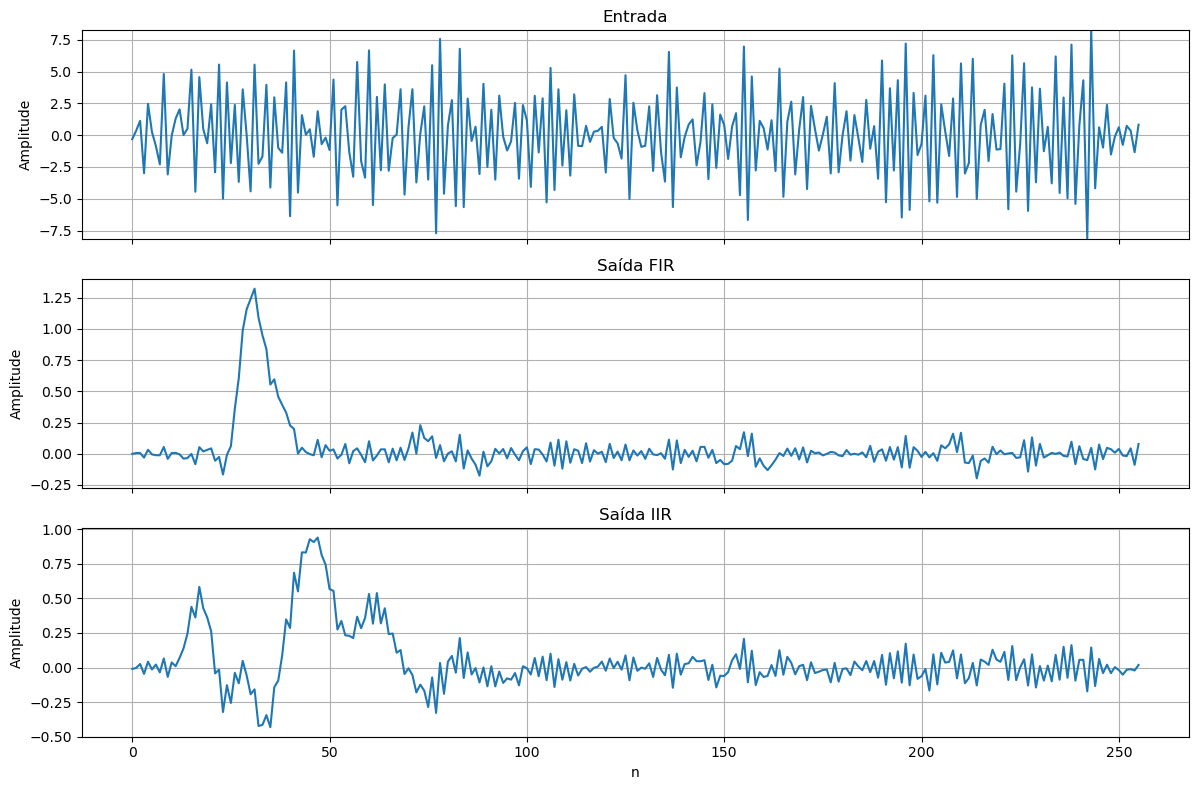

In [14]:
plt.figure(figsize=(12,4))

plt.plot(pnd_1, label='Entrada')
plt.plot(radar_fir, label='FIR')
plt.plot(radar_iir, label='IIR')

plt.legend()
plt.grid()

plt.show()

fig, ax = plt.subplots(
    3,
    1,
    figsize=(12,8),
    sharex=True
)

# Escala comum
ymin = min(
    np.min(pnd_1),
    np.min(radar_fir),
    np.min(radar_iir)
)

ymax = max(
    np.max(pnd_1),
    np.max(radar_fir),
    np.max(radar_iir)
)

ax[0].plot(pnd_1)
ax[0].set_title('Entrada')
ax[0].set_ylabel('Amplitude')
ax[0].set_ylim(ymin, ymax)
ax[0].grid()

ax[1].plot(radar_fir)
ax[1].set_title('Saída FIR')
ax[1].set_ylabel('Amplitude')
ax[1].grid()

ax[2].plot(radar_iir)
ax[2].set_title('Saída IIR')
ax[2].set_ylabel('Amplitude')
ax[2].set_xlabel('n')
ax[2].grid()

plt.tight_layout()
plt.show()

In [15]:
idx_fir = np.argmax(np.abs(radar_fir))
idx_iir = np.argmax(np.abs(radar_iir))

print("Pico FIR :", idx_fir)
print("Pico IIR :", idx_iir)

Pico FIR : 31
Pico IIR : 47


Os filtros FIR e IIR apresentaram respostas em magnitude semelhantes e foram igualmente capazes de reduzir o ruído presente no sinal. Entretanto, a análise do atraso de grupo revelou diferenças importantes entre eles.

O filtro FIR apresentou atraso de grupo aproximadamente constante (16 amostras), característica associada à fase linear. Como consequência, a forma temporal dos sinais foi preservada após a filtragem. Isso pôde ser observado tanto no pulso de teste, cuja forma foi mantida com apenas um atraso aproximadamente constante, quanto no sinal de radar, que resultou em um pico único e bem definido na saída filtrada.

Por outro lado, o filtro IIR apresentou atraso de grupo dependente da frequência. Embora sua capacidade de atenuação do ruído tenha sido semelhante à do FIR, a variação do atraso entre as componentes espectrais provocou distorções temporais nos sinais processados. No caso do pulso, observou-se o surgimento de oscilações antes e após o pico principal, indicando espalhamento temporal da energia do sinal. Esse mesmo efeito foi observado no sinal de radar, resultando em um eco menos concentrado e em um deslocamento do instante do pico detectado.

Os resultados obtidos demonstram que, em aplicações de radar e estimação de atraso, não basta considerar apenas a resposta em magnitude dos filtros. A preservação da informação temporal também é fundamental. Dessa forma, o filtro FIR mostrou-se mais adequado para esse tipo de aplicação, pois combina boa rejeição de ruído com preservação da forma de onda e localização temporal mais precisa dos ecos.

Vale ressaltar que a escolha do filtro FIR neste trabalho está relacionada aos requisitos específicos da aplicação analisada. Em geral, filtros IIR podem atingir respostas em magnitude semelhantes utilizando ordens menores e, consequentemente, menor custo computacional. Entretanto, para aplicações que dependem da preservação da forma temporal dos sinais e da estimação precisa de atrasos, como sistemas de radar, a característica de fase linear e atraso de grupo aproximadamente constante dos filtros FIR torna-se uma vantagem decisiva.